In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import os, pickle
os.makedirs("data", exist_ok=True)
print("Everything is ready.")


Everything is ready.


## Step 1 — Load Dataset

In [14]:
df = pd.read_csv("dataset/crop_disease_dataset.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)

Shape: (552, 12)
Columns: ['crop_type', 'region', 'disease_label', 'disease_severity', 'fertilizer_used', 'soil_ph', 'nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'rainfall']

First 5 rows:
  crop_type    region disease_label disease_severity fertilizer_used  soil_ph  \
0      Rice     Terai       Healthy              NaN              No     5.93   
1    Millet  Mountain       Healthy              NaN              No     5.78   
2      Rice     Terai    Sheath Rot           Medium              No     5.87   
3    Tomato     Hilly     Leaf Curl           Medium              No     6.60   
4    Cotton     Terai     Leaf Spot              Low             Yes     6.11   

   nitrogen  phosphorus  potassium  temperature  humidity  rainfall  
0      96.0          31         32         35.0      80.8     230.9  
1      61.0          38         36         34.1      50.0      90.2  
2       NaN          43         51         26.7      76.8     177.9  
3      87.0          76

## Step 2 — Explore & Clean

- Missing Values:
      disease_severity    : 156 missing  (28.3%)
      soil_ph             :  23 missing  (4.2%)
      nitrogen            :  28 missing  (5.1%)
      humidity            :  26 missing  (4.7%)
      rainfall            :  32 missing  (5.8%)
Total missing cells : 265

- Descriptive Statistics:
       soil_ph  nitrogen  phosphorus  potassium  temperature  humidity  \
count   529.00    524.00      552.00     552.00       552.00    526.00   
mean      6.49     93.31       51.05      55.87        23.97     66.25   
std       0.60     25.06       13.83      24.55         6.91     11.92   
min       4.82     30.00       20.00      20.00        10.00     40.10   
25%       6.11     75.75       41.00      39.00        19.18     57.52   
50%       6.47     94.00       51.00      50.00        24.70     66.35   
75%       6.93    111.00       58.25      65.00        29.40     74.60   
max       7.94    149.00       89.00     139.00        37.70     94.80   

       rainfall  
cou

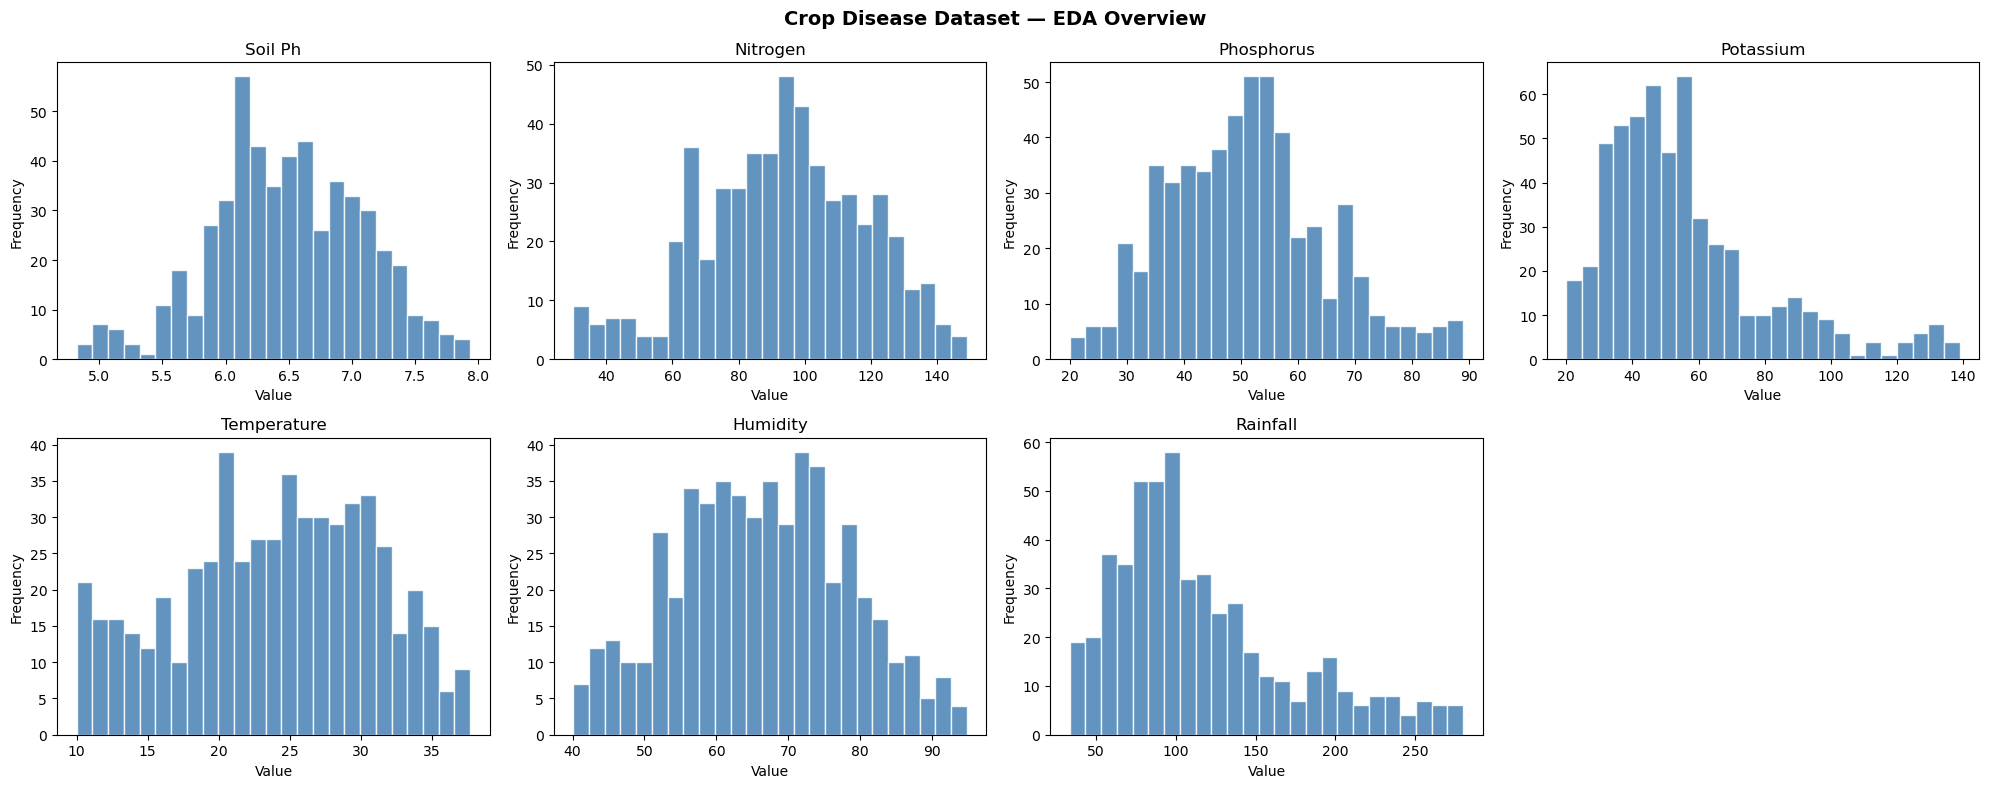


  Saved: data/eda_overview.png


In [16]:
# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print("- Missing Values:")
for col in df.columns:
    if missing[col] > 0:
        print(f"      {col:20s}: {missing[col]:3d} missing  ({missing_pct[col]:.1f}%)")
print(f"Total missing cells : {missing.sum()}")

# Descriptive statistics
print(f"\n- Descriptive Statistics:")
print(df.describe().round(2))

# Class (disease_label) distribution
dist = df['disease_label'].value_counts()
print(f"\n- Disease Label Distribution  (18 unique classes):")
for label, cnt in dist.items():
    print(f"      {label:20s}: {cnt:4d}  ({cnt/len(df)*100:.1f}%)")

# Duplicate rows
dup_count = df.duplicated().sum()
print(f"\n- Duplicate rows : {dup_count}")

# EDA overview plot
num_cols = ['soil_ph', 'nitrogen', 'phosphorus', 'potassium',
            'temperature', 'humidity', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Crop Disease Dataset — EDA Overview", fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off') 
plt.tight_layout()
plt.savefig("data/eda_overview.png", dpi=130, bbox_inches='tight')
plt.show()
print("\n  Saved: data/eda_overview.png")


## Step 3 — Preprocessing

- Duplicates removed : 4  rows  (552 → 548)
- soil_ph        : 23 NaN → median (6.47)
- nitrogen       : 28 NaN → median (94.00)
- humidity       : 26 NaN → median (66.25)
- rainfall       : 31 NaN → median (99.90)
- disease_severity  : 155 NaN → mode ('Medium')
- phosphorus     : clipped  [20.0, 89.0]  →  [20.0, 84.1]
- potassium      : clipped  [20.0, 139.0]  →  [20.0, 104.0]
- rainfall       : clipped  [33.6, 280.0]  →  [33.6, 232.8]
- soil_ph        : clipped  [4.8, 7.9]  →  [4.9, 7.9]
- crop_type           : ['Cotton', 'Maize', 'Millet', 'Mustard', 'Potato', 'Rice', 'Tomato', 'Wheat']
- region              : ['Hilly', 'Mountain', 'Terai']
- disease_severity    : ['High', 'Low', 'Medium']
- fertilizer_used     : ['No', 'Yes']

- disease_label classes  : ['Blast', 'Blight', 'Boll Rot', 'Downy Mildew', 'Early Blight', 'Healthy', 'Late Blight', 'Leaf Curl', 'Leaf Spot', 'Mosaic', 'Powdery Mildew', 'Rust', 'Scab', 'Sheath Rot', 'Smut', 'Stalk Rot', 'White Rust', 'Wilt']

label_encoders

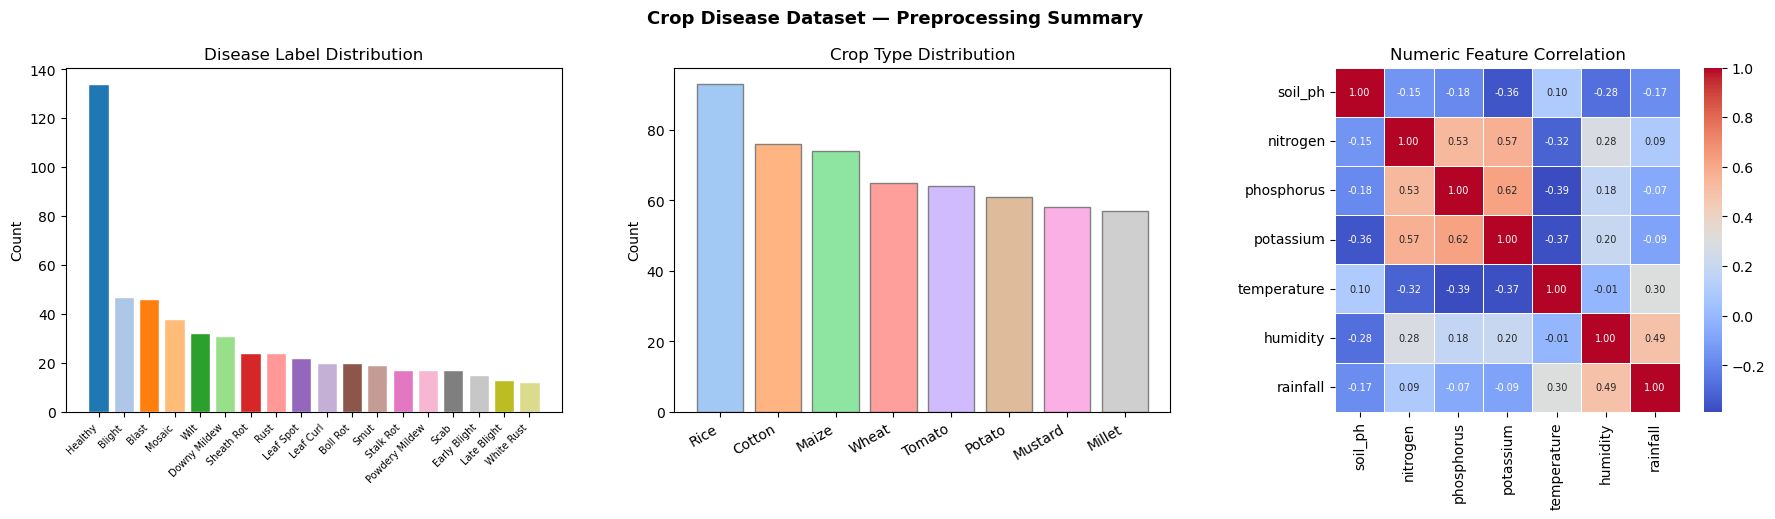


  Saved: data/preprocessing_summary.png


In [17]:
df_clean = df.copy()

# Remove duplicate rows
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f"- Duplicates removed : {before - len(df_clean)}  rows  "
      f"({before} → {len(df_clean)})")

# Impute missing numeric columns with MEDIAN 
num_missing_cols = ['soil_ph', 'nitrogen', 'humidity', 'rainfall']
for col in num_missing_cols:
    med = df_clean[col].median()
    filled = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(med)
    print(f"- {col:15s}: {filled} NaN → median ({med:.2f})")

# Impute missing categorical column with MODE 
mode_val = df_clean['disease_severity'].mode()[0]
filled_sev = df_clean['disease_severity'].isnull().sum()
df_clean['disease_severity'] = df_clean['disease_severity'].fillna(mode_val)
print(f"- disease_severity  : {filled_sev} NaN → mode ('{mode_val}')")

# Cap outliers with IQR Winsorisation 
outlier_cols = ['phosphorus', 'potassium', 'rainfall', 'soil_ph']
for col in outlier_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    before_min, before_max = df_clean[col].min(), df_clean[col].max()
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)
    print(f"- {col:15s}: clipped  [{before_min:.1f}, {before_max:.1f}]"
          f"  →  [{df_clean[col].min():.1f}, {df_clean[col].max():.1f}]")

# Encode categorical columns 
le = LabelEncoder()
df_enc = df_clean.copy()
cat_cols = ['crop_type', 'region', 'disease_severity', 'fertilizer_used']
label_encoders = {}

for col in cat_cols:
    le_col = LabelEncoder()
    df_enc[col] = le_col.fit_transform(df_enc[col])
    label_encoders[col] = le_col
    print(f"- {col:20s}: {list(le_col.classes_)}")

# Target column — encode separately and store mapping
le_target = LabelEncoder()
df_enc['disease_label'] = le_target.fit_transform(df_enc['disease_label'])
label_encoders['disease_label'] = le_target
print(f"\n- disease_label classes  : {list(le_target.classes_)}")

# Save encoders for reuse in classification
with open('data/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("\nlabel_encoders.pkl saved to data/")

# Feature engineering 
df_enc['npk_ratio']= (df_enc['nitrogen'] /(df_enc['phosphorus'] + df_enc['potassium'] + 1))
df_enc['heat_humidity_index'] = (df_enc['temperature'] * df_enc['humidity']) / 100
print("- Feature engineering complete  (npk_ratio, heat_humidity_index added)")

# Standardise numeric features 
TARGET       = 'disease_label'
feature_cols = [c for c in df_enc.columns if c != TARGET]
X            = df_enc[feature_cols].values
y            = df_enc[TARGET].values
print(f"- Features : {len(feature_cols)} columns")
print(f"Feature list: {feature_cols}")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\n- StandardScaler applied  (mean≈0, std≈1)")

# Save scaler + feature order
with open('data/scaler.pkl', 'wb') as f:
    pickle.dump((scaler, feature_cols), f)
print(f"- Scaler saved to data/scaler.pkl")

# Preprocessing summary plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Crop Disease Dataset — Preprocessing Summary", fontsize=13, fontweight='bold')

# Disease label distribution
disease_counts = df_clean['disease_label'].value_counts()
axes[0].bar(disease_counts.index, disease_counts.values,
            color=sns.color_palette("tab20", len(disease_counts)), edgecolor='white')
axes[0].set_xticklabels(disease_counts.index, rotation=45, ha='right', fontsize=7)
axes[0].set_title("Disease Label Distribution")
axes[0].set_ylabel("Count")

# Crop type distribution
crop_counts = df_clean['crop_type'].value_counts()
axes[1].bar(crop_counts.index, crop_counts.values,
            color=sns.color_palette("pastel"), edgecolor='grey')
axes[1].set_title("Crop Type Distribution")
axes[1].set_xticklabels(crop_counts.index, rotation=30, ha='right')
axes[1].set_ylabel("Count")

# Correlation heatmap of numeric features
num_cols_clean = ['soil_ph', 'nitrogen', 'phosphorus', 'potassium',
                  'temperature', 'humidity', 'rainfall']
corr = df_clean[num_cols_clean].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, ax=axes[2], annot_kws={"size": 7}, square=True)
axes[2].set_title("Numeric Feature Correlation")

plt.tight_layout()
plt.savefig("data/preprocessing_summary.png", dpi=130, bbox_inches='tight')
plt.show()
print("\n  Saved: data/preprocessing_summary.png")


## Step 4 — Train/Test Split & Save CSVs

In [19]:
# Split — 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"- Train size : {len(X_train)} samples")
print(f"Test size  : {len(X_test)}  samples")
print(f"Train class balance (unique classes) : {len(set(y_train))}")
print(f"Test  class balance (unique classes) : {len(set(y_test))}")

# Save cleaned_data.csv
cleaned = pd.DataFrame(X_scaled, columns=feature_cols)
cleaned['disease_label'] = y
cleaned.to_csv("data/cleaned_data.csv", index=False)
print(f"\n- Saved: data/cleaned_data.csv  ({cleaned.shape})")

# Save train.csv
train_df = pd.DataFrame(X_train, columns=feature_cols)
train_df['disease_label'] = y_train
train_df.to_csv("data/train.csv", index=False)
print(f"- Saved: data/train.csv  ({train_df.shape})")

# Save test.csv
test_df = pd.DataFrame(X_test, columns=feature_cols)
test_df['disease_label'] = y_test
test_df.to_csv("data/test.csv", index=False)
print(f"- Saved: data/test.csv  ({test_df.shape})")

print("\nData preparation complete.")


- Train size : 438 samples
Test size  : 110  samples
Train class balance (unique classes) : 18
Test  class balance (unique classes) : 18

- Saved: data/cleaned_data.csv  ((548, 14))
- Saved: data/train.csv  ((438, 14))
- Saved: data/test.csv  ((110, 14))

Data preparation complete.
